# Time Series Structure and Exploration From Scratch

## 1. Why Time Series Need Their Own Foundations

Time-series data are different from ordinary tabular data because **order matters**.

If we shuffle ordinary classification rows, the meaning of each row is usually unchanged. If we shuffle a time series, we destroy the temporal relationships that define the problem.

This notebook begins with temporal structure before any forecasting model is introduced.

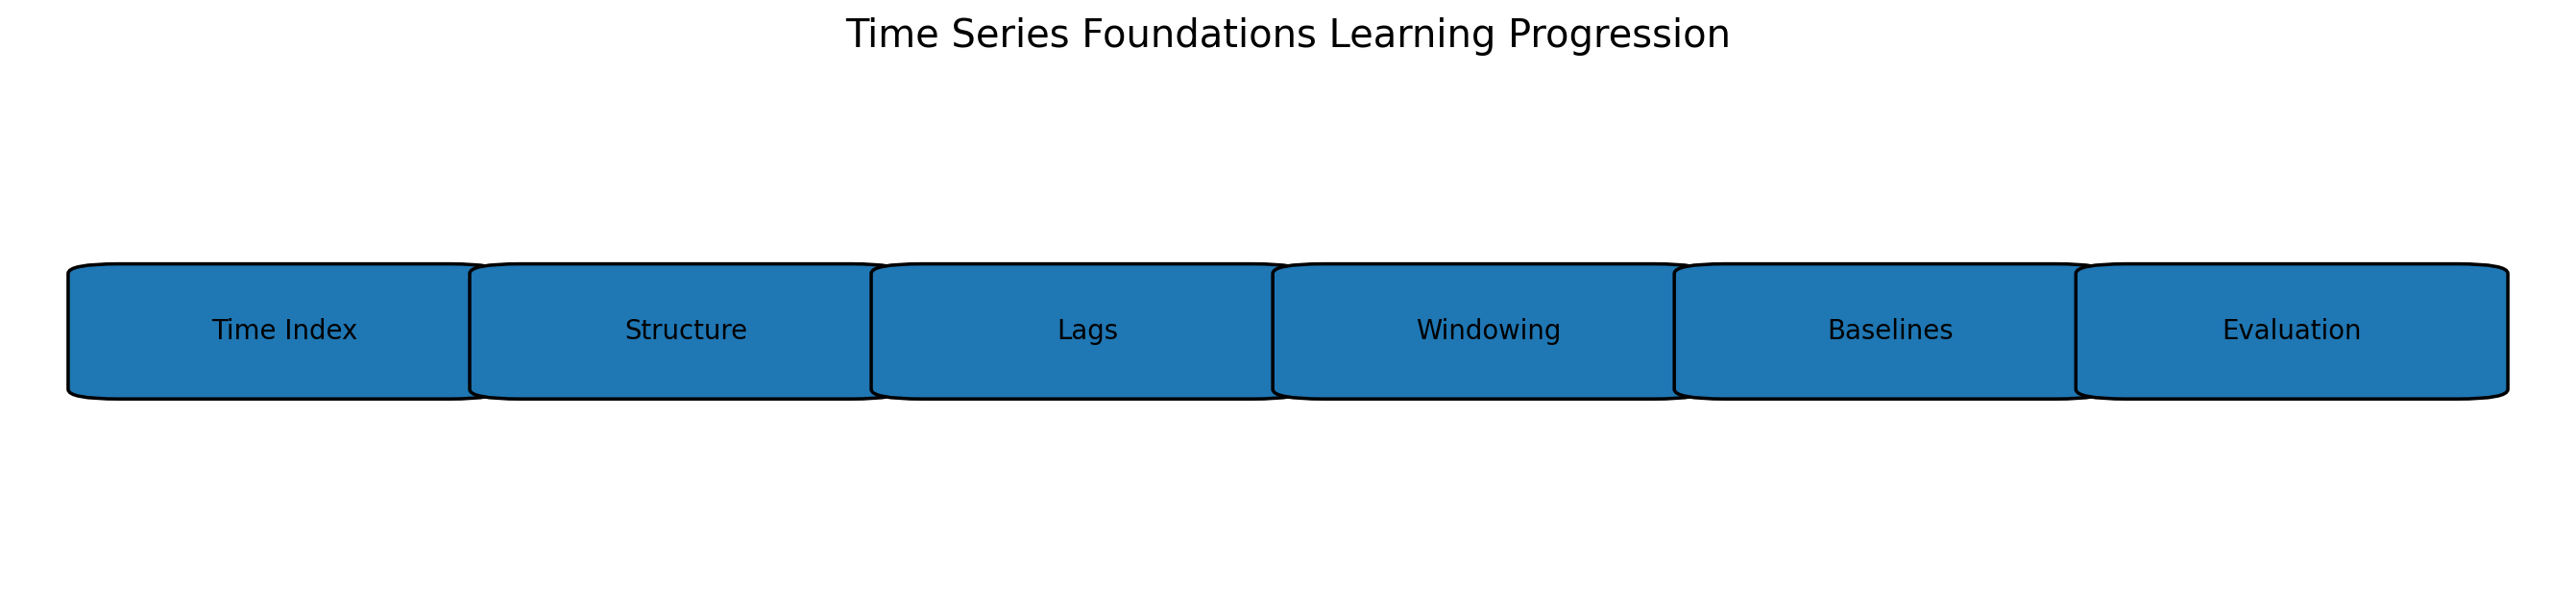

## 2. Learning Objectives

By the end of this notebook, you should be able to:

- explain what makes a time series different from ordinary tabular data,
- identify a time index and temporal frequency,
- distinguish regular and irregular time series,
- recognize trend, seasonality, cycles, and noise,
- create and interpret lags,
- calculate autocorrelation manually,
- interpret rolling statistics,
- explain stationarity and differencing,
- detect missing timestamps and missing values,
- resample a time series,
- understand why external variables require forecast-time availability.

## 3. What Is a Time Series?

A time series is an ordered sequence:

$$
y_1, y_2, \ldots, y_T
$$

Examples include hourly energy demand, daily sales, machine-sensor readings, wind speed, and hospital arrivals.

The key difference is that the current observation may depend on previous observations.

## 4. A Small Manual Example

```text
Time:   1   2   3   4   5
Value: 10  12  11  15  17
```

The sequence itself carries information.

In [1]:
time = [1, 2, 3, 4, 5]

values = [10, 12, 11, 15, 17]

print("Time:")
print(time)

print()

print("Values:")
print(values)

Time:
[1, 2, 3, 4, 5]

Values:
[10, 12, 11, 15, 17]


## 5. Why Random Shuffling Is Dangerous

```text
Original:
10 → 12 → 11 → 15 → 17

Shuffled:
15 → 10 → 17 → 11 → 12
```

The shuffled sequence is not the same temporal problem. This is why later train/test splitting must preserve chronology.

## 6. Load the Dataset

This folder contains a reproducible synthetic hourly demand series. It includes trend, daily seasonality, weekly seasonality, noise, temperature, humidity, and a few deliberately missing demand measurements.

A synthetic dataset is useful here because we know the structure that should be discovered.

In [3]:
"""import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = "data/synthetic_hourly_demand.csv"

data = pd.read_csv(data_path)

print("Dataset type:")
print(type(data))

print()

print("Dataset shape:")
print(data.shape)

print()

print(data.head())"""

'import pandas as pd\nimport numpy as np\nimport matplotlib.pyplot as plt\n\ndata_path = "data/synthetic_hourly_demand.csv"\n\ndata = pd.read_csv(data_path)\n\nprint("Dataset type:")\nprint(type(data))\n\nprint()\n\nprint("Dataset shape:")\nprint(data.shape)\n\nprint()\n\nprint(data.head())'

In [4]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

print("Uploaded file:")
print(file_name)

data = pd.read_csv(file_name)

print("Dataset type:")
print(type(data))

print()

print("Dataset shape:")
print(data.shape)

print()

print(data.head())

Saving synthetic_hourly_demand.csv to synthetic_hourly_demand.csv
Uploaded file:
synthetic_hourly_demand.csv
Dataset type:
<class 'pandas.core.frame.DataFrame'>

Dataset shape:
(2880, 4)

             timestamp     demand  temperature   humidity
0  2024-01-01 00:00:00  54.247024    15.695400  62.063680
1  2024-01-01 01:00:00  57.721087    15.044949  61.358504
2  2024-01-01 02:00:00  56.020419    16.844586  63.553905
3  2024-01-01 03:00:00  56.303220    19.182494  64.144216
4  2024-01-01 04:00:00  60.937876    18.172185  53.719428


## 7. Convert the Timestamp

CSV files often store timestamps as text. Temporal analysis should use a datetime type.

In [5]:
print("Data types before conversion:")
print(data.dtypes)

data["timestamp"] = pd.to_datetime(data["timestamp"])

print()

print("Data types after conversion:")
print(data.dtypes)

Data types before conversion:
timestamp       object
demand         float64
temperature    float64
humidity       float64
dtype: object

Data types after conversion:
timestamp      datetime64[ns]
demand                float64
temperature           float64
humidity              float64
dtype: object


## 8. Set the Time Index

In [6]:
data = data.set_index("timestamp")

print("Index type:")
print(type(data.index))

print()

print(data.head())

Index type:
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>

                        demand  temperature   humidity
timestamp                                             
2024-01-01 00:00:00  54.247024    15.695400  62.063680
2024-01-01 01:00:00  57.721087    15.044949  61.358504
2024-01-01 02:00:00  56.020419    16.844586  63.553905
2024-01-01 03:00:00  56.303220    19.182494  64.144216
2024-01-01 04:00:00  60.937876    18.172185  53.719428


## 9. Inspect the Time Range

In [7]:
start_time = data.index.min()

end_time = data.index.max()

print("Start time:")
print(start_time)

print()

print("End time:")
print(end_time)

print()

print("Number of observations:")
print(len(data))

Start time:
2024-01-01 00:00:00

End time:
2024-04-29 23:00:00

Number of observations:
2880


## 10. Temporal Frequency

Frequency describes how often observations occur.

Examples:

```text
1 minute
1 hour
1 day
1 week
1 month
```

A regular time series has observations at consistent intervals.

In [8]:
time_differences = data.index.to_series().diff()

print("First ten time differences:")
print(time_differences.head(10))

print()

most_common_difference = time_differences.value_counts().index[0]

print("Most common time difference:")
print(most_common_difference)

First ten time differences:
timestamp
2024-01-01 00:00:00               NaT
2024-01-01 01:00:00   0 days 01:00:00
2024-01-01 02:00:00   0 days 01:00:00
2024-01-01 03:00:00   0 days 01:00:00
2024-01-01 04:00:00   0 days 01:00:00
2024-01-01 05:00:00   0 days 01:00:00
2024-01-01 06:00:00   0 days 01:00:00
2024-01-01 07:00:00   0 days 01:00:00
2024-01-01 08:00:00   0 days 01:00:00
2024-01-01 09:00:00   0 days 01:00:00
Name: timestamp, dtype: timedelta64[ns]

Most common time difference:
0 days 01:00:00


## 11. Regular vs Irregular Time Series

### Regular

```text
08:00
09:00
10:00
11:00
```

### Irregular

```text
08:00
08:17
10:42
11:03
```

Many forecasting workflows assume a regular time grid. Irregular data may require resampling or specialized methods.

## 12. Plot the Entire Series

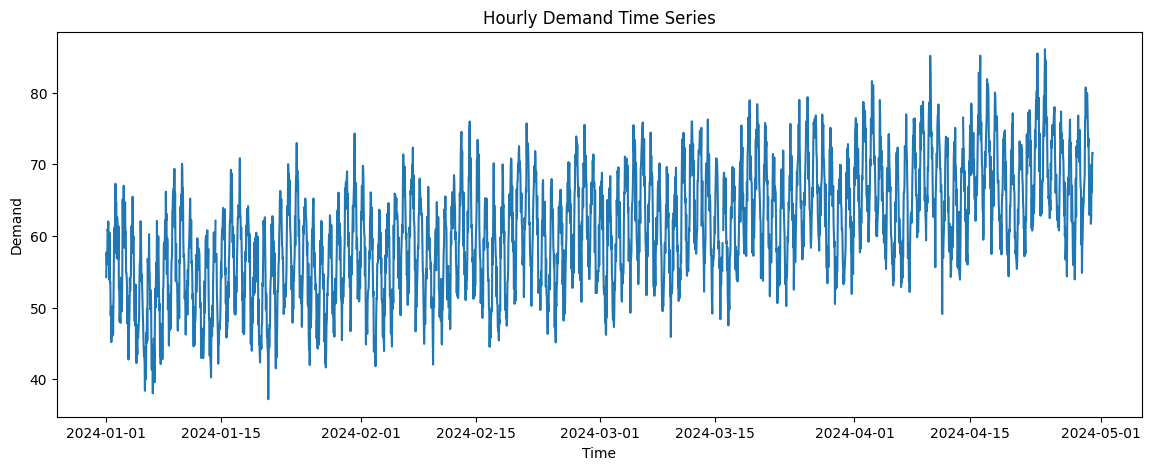

In [9]:
plt.figure(figsize=(14, 5))

plt.plot(data.index, data["demand"])

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("Hourly Demand Time Series")

plt.show()

A long plot can hide short repeating patterns. Time-series exploration should therefore inspect multiple scales.

## 13. Zoom Into One Week

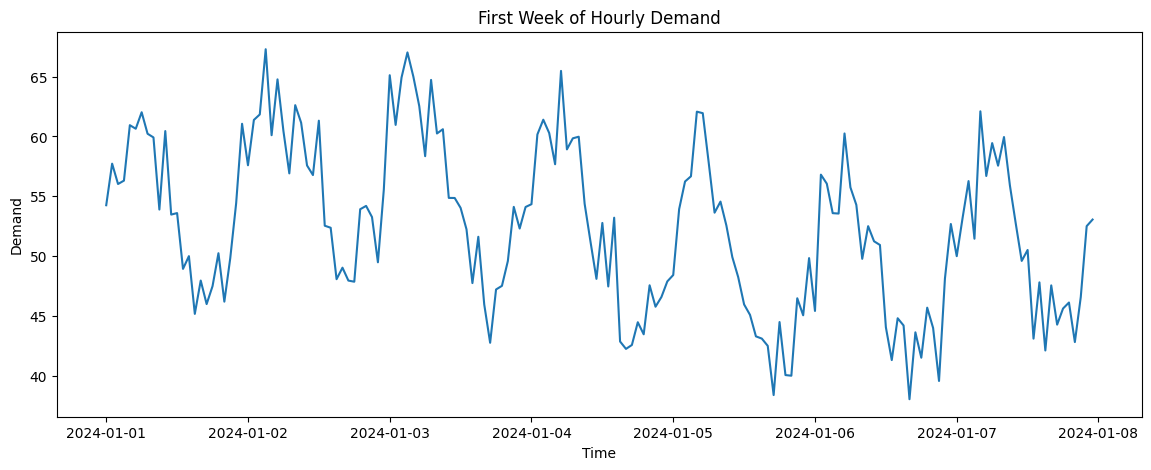

In [10]:
one_week = data.iloc[:24 * 7]

plt.figure(figsize=(14, 5))

plt.plot(one_week.index, one_week["demand"])

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("First Week of Hourly Demand")

plt.show()

## 14. Time-Series Components

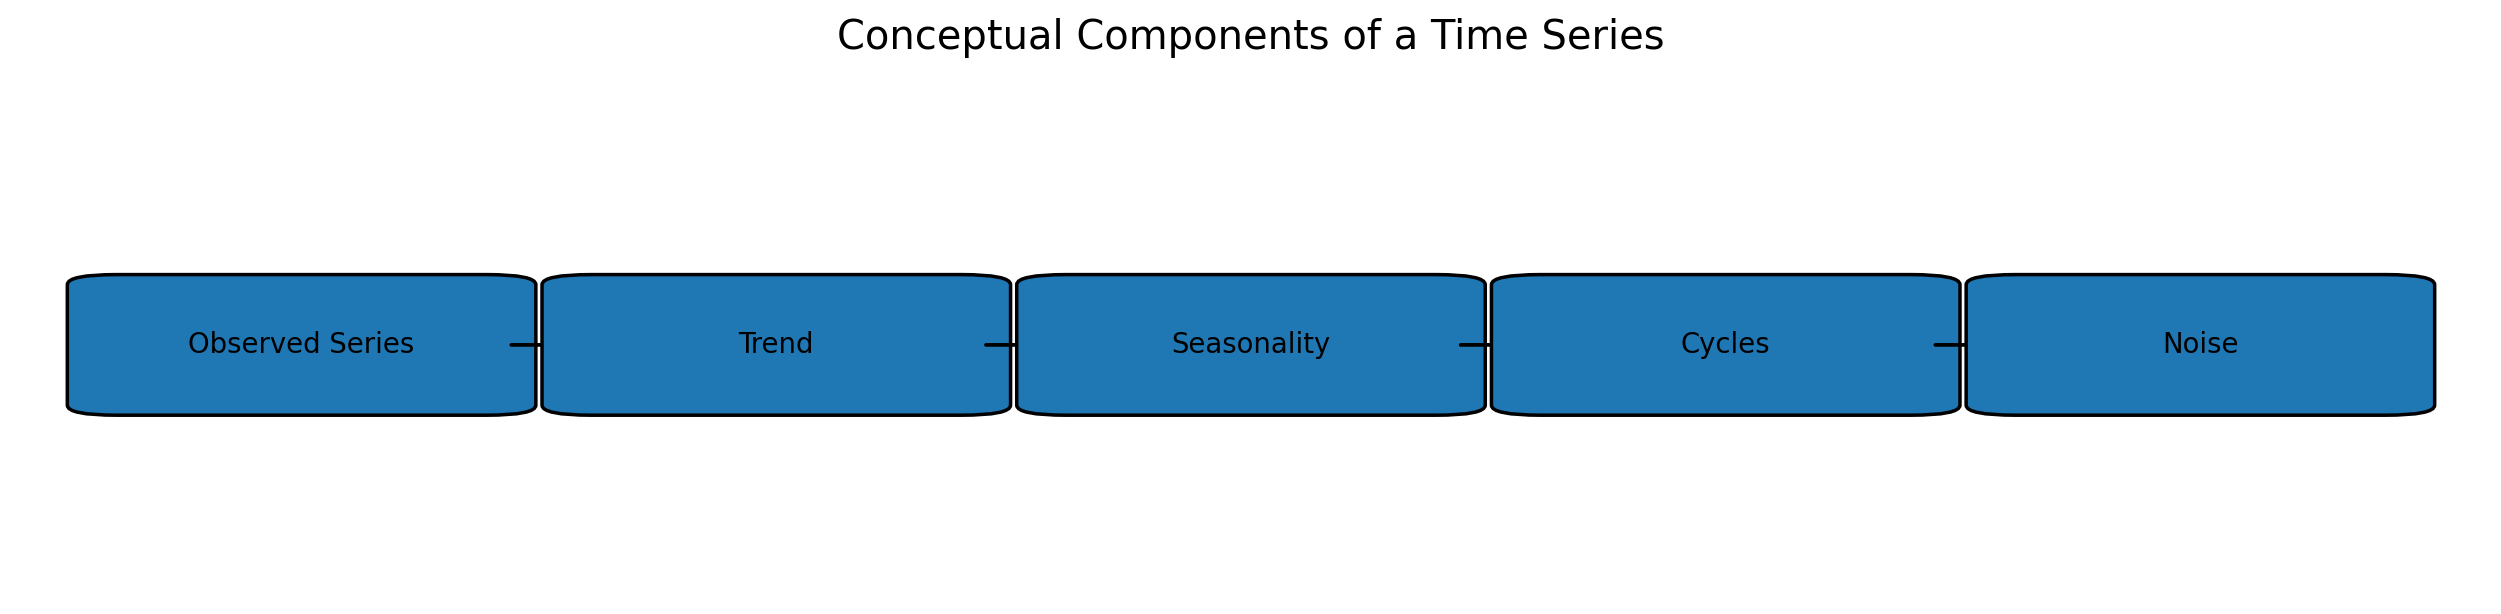

### Trend
Long-term increase or decrease.

### Seasonality
A repeating pattern at a known period.

### Cycles
Longer fluctuations without a fixed repeating period.

### Noise
Short-term unpredictable variation.

## 15. Reveal the Trend With a Rolling Mean

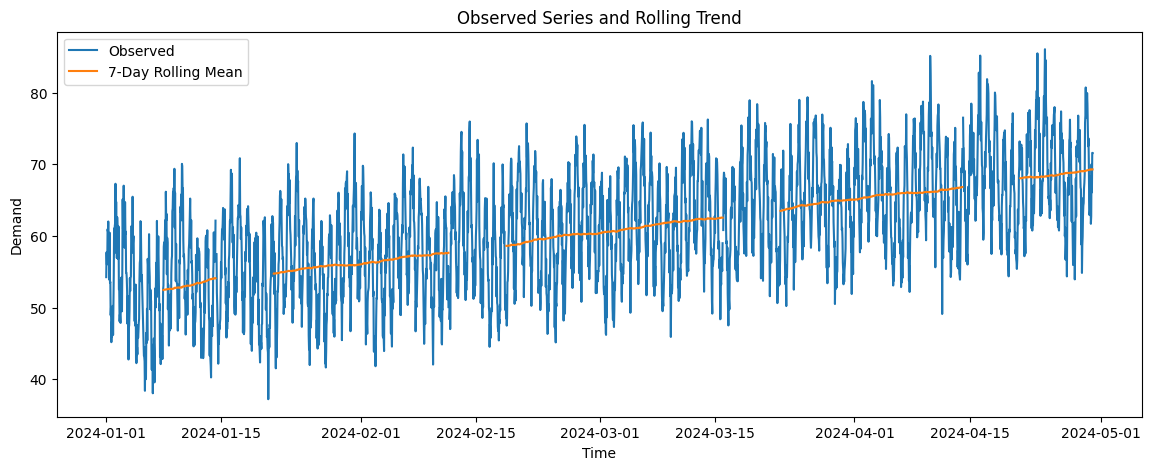

In [11]:
rolling_window = 24 * 7

rolling_mean = data["demand"].rolling(window=rolling_window).mean()

plt.figure(figsize=(14, 5))

plt.plot(data.index, data["demand"], label="Observed")

plt.plot(data.index, rolling_mean, label="7-Day Rolling Mean")

plt.xlabel("Time")
plt.ylabel("Demand")
plt.title("Observed Series and Rolling Trend")
plt.legend()

plt.show()

## 16. Daily Seasonality

For hourly data, one day has 24 observations. Average demand by hour can reveal a daily pattern.

In [12]:
hourly_profile = data.copy()

hourly_profile["hour"] = hourly_profile.index.hour

average_by_hour = hourly_profile.groupby("hour")["demand"].mean()

print(average_by_hour)

hour
0     63.256461
1     64.984877
2     67.131219
3     68.157234
4     68.515916
5     69.369816
6     68.523599
7     68.388421
8     66.509744
9     64.769971
10    62.997637
11    61.166470
12    59.198589
13    56.764810
14    55.456616
15    53.789940
16    53.139040
17    52.683743
18    53.149210
19    54.081507
20    55.404959
21    56.825594
22    59.042937
23    61.237209
Name: demand, dtype: float64


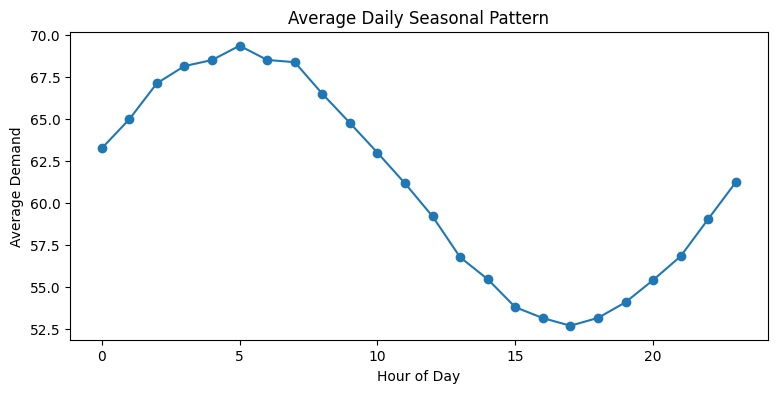

In [13]:
plt.figure(figsize=(9, 4))

plt.plot(average_by_hour.index, average_by_hour.values, marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand")
plt.title("Average Daily Seasonal Pattern")

plt.show()

## 17. Weekly Seasonality

In [14]:
weekly_profile = data.copy()

weekly_profile["day_of_week"] = weekly_profile.index.dayofweek

average_by_day = weekly_profile.groupby("day_of_week")["demand"].mean()

print(average_by_day)

day_of_week
0    62.574835
1    64.355002
2    64.065037
3    61.026746
4    57.989667
5    57.474926
6    59.531128
Name: demand, dtype: float64


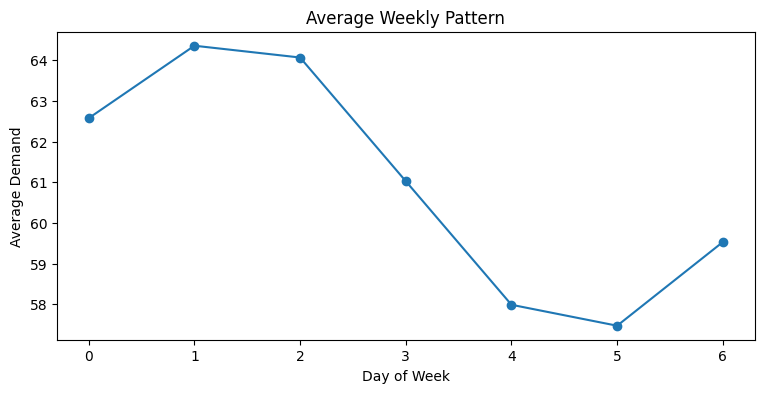

In [15]:
plt.figure(figsize=(9, 4))

plt.plot(average_by_day.index, average_by_day.values, marker="o")

plt.xlabel("Day of Week")
plt.ylabel("Average Demand")
plt.title("Average Weekly Pattern")

plt.show()

## 18. What Is a Lag?

A lag is a previous observation.

$$
lag_1(t)=y_{t-1}
$$

For hourly data:

- lag 1 = one hour ago,
- lag 24 = one day ago,
- lag 168 = one week ago.

## 19. Create Lag 1 Manually

In [16]:
example_values = [10, 12, 14, 16, 18]

lag_1_values = [None]

for index in range(1, len(example_values)):
    previous_value = example_values[index - 1]
    lag_1_values.append(previous_value)

print("Original:")
print(example_values)

print()

print("Lag 1:")
print(lag_1_values)

Original:
[10, 12, 14, 16, 18]

Lag 1:
[None, 10, 12, 14, 16]


## 20. Create Several Lags With Pandas

In [17]:
lag_example = data[["demand"]].copy()

lag_example["lag_1"] = lag_example["demand"].shift(1)

lag_example["lag_24"] = lag_example["demand"].shift(24)

lag_example["lag_168"] = lag_example["demand"].shift(168)

print(lag_example.head(170))

                        demand      lag_1     lag_24    lag_168
timestamp                                                      
2024-01-01 00:00:00  54.247024        NaN        NaN        NaN
2024-01-01 01:00:00  57.721087  54.247024        NaN        NaN
2024-01-01 02:00:00  56.020419  57.721087        NaN        NaN
2024-01-01 03:00:00  56.303220  56.020419        NaN        NaN
2024-01-01 04:00:00  60.937876  56.303220        NaN        NaN
...                        ...        ...        ...        ...
2024-01-07 21:00:00  46.575344  42.809858  39.556064        NaN
2024-01-07 22:00:00  52.499246  46.575344  48.107218        NaN
2024-01-07 23:00:00  53.049652  52.499246  52.677373        NaN
2024-01-08 00:00:00  58.496312  53.049652  49.989344  54.247024
2024-01-08 01:00:00  59.098495  58.496312  53.217526  57.721087

[170 rows x 4 columns]


## 21. Autocorrelation

Autocorrelation measures how strongly the series is related to a lagged version of itself.

$$
ho_k = Corr(y_t, y_{t-k})
$$

A strong correlation at lag 24 can indicate daily repetition in hourly data.

## 22. Calculate Lag-1 Correlation Manually

In [18]:
clean_demand = data["demand"].dropna()

current_values = clean_demand.iloc[1:].to_numpy()

previous_values = clean_demand.iloc[:-1].to_numpy()

current_mean = current_values.mean()

previous_mean = previous_values.mean()

numerator = np.sum(
    (current_values - current_mean) * (previous_values - previous_mean)
)

current_squared = np.sum((current_values - current_mean) ** 2)

previous_squared = np.sum((previous_values - previous_mean) ** 2)

denominator = np.sqrt(current_squared * previous_squared)

manual_correlation = numerator / denominator

print("Manual lag-1 autocorrelation:")
print(manual_correlation)

Manual lag-1 autocorrelation:
0.8992765809804056


## 23. Compare Important Lags

In [19]:
lags_to_check = [1, 2, 6, 12, 24, 48, 72, 168]

autocorrelations = []

for lag in lags_to_check:
    value = clean_demand.autocorr(lag=lag)
    autocorrelations.append(value)

    print("Lag:", lag, "| Autocorrelation:", round(value, 4))

Lag: 1 | Autocorrelation: 0.8993
Lag: 2 | Autocorrelation: 0.8541
Lag: 6 | Autocorrelation: 0.4475
Lag: 12 | Autocorrelation: -0.0243
Lag: 24 | Autocorrelation: 0.872
Lag: 48 | Autocorrelation: 0.7725
Lag: 72 | Autocorrelation: 0.6947
Lag: 168 | Autocorrelation: 0.9048


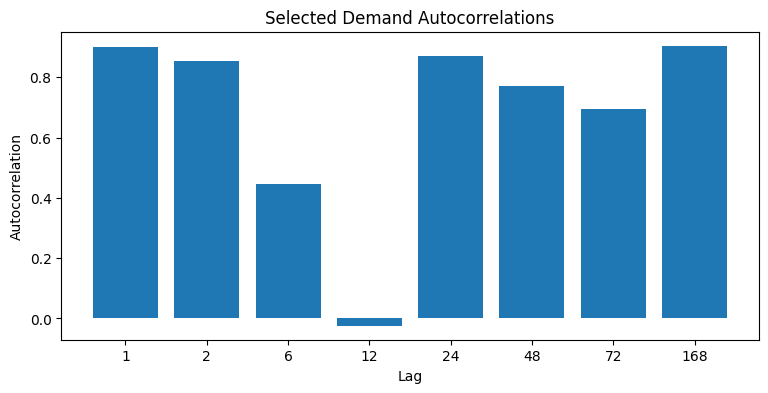

In [20]:
plt.figure(figsize=(9, 4))

plt.bar([str(lag) for lag in lags_to_check], autocorrelations)

plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Selected Demand Autocorrelations")

plt.show()

## 24. Rolling Mean and Rolling Standard Deviation

Rolling statistics describe local behavior. They are useful for noticing changing level and changing variability.

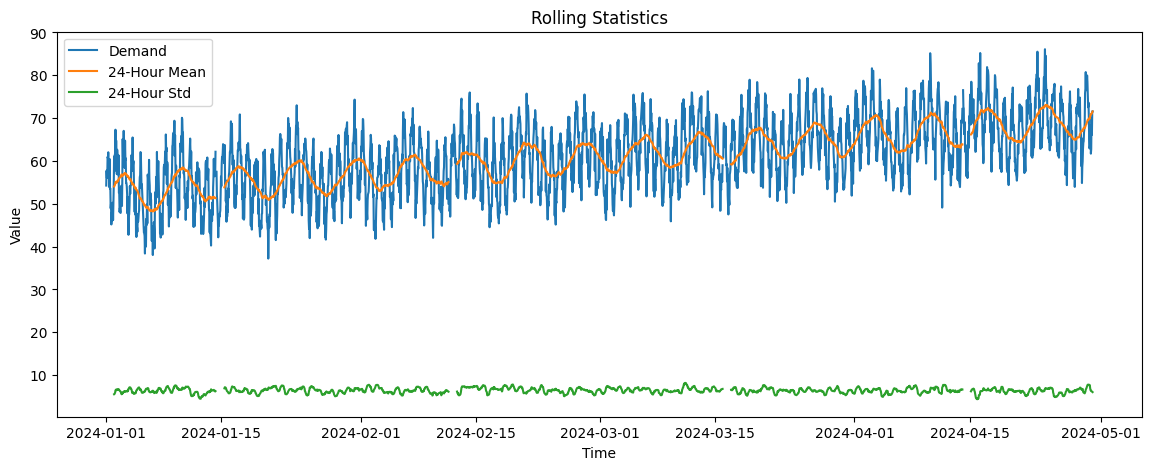

In [21]:
rolling_mean_24 = data["demand"].rolling(window=24).mean()

rolling_std_24 = data["demand"].rolling(window=24).std()

plt.figure(figsize=(14, 5))

plt.plot(data.index, data["demand"], label="Demand")

plt.plot(data.index, rolling_mean_24, label="24-Hour Mean")

plt.plot(data.index, rolling_std_24, label="24-Hour Std")

plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Rolling Statistics")
plt.legend()

plt.show()

## 25. Stationarity

Strict stationarity has a formal distributional definition. For practical forecasting, a useful first question is:

> Does the statistical behavior remain reasonably stable over time?

Nonstationarity may appear as changing mean, changing variance, persistent trend, or evolving seasonal structure.

Deep learning does not remove the need to understand this issue.

## 26. First Differencing

$$
\Delta y_t = y_t-y_{t-1}
$$

Differencing focuses on change rather than absolute level and can reduce trend.

In [22]:
differenced_demand = data["demand"].diff()

print(differenced_demand.head())

timestamp
2024-01-01 00:00:00         NaN
2024-01-01 01:00:00    3.474063
2024-01-01 02:00:00   -1.700668
2024-01-01 03:00:00    0.282801
2024-01-01 04:00:00    4.634655
Name: demand, dtype: float64


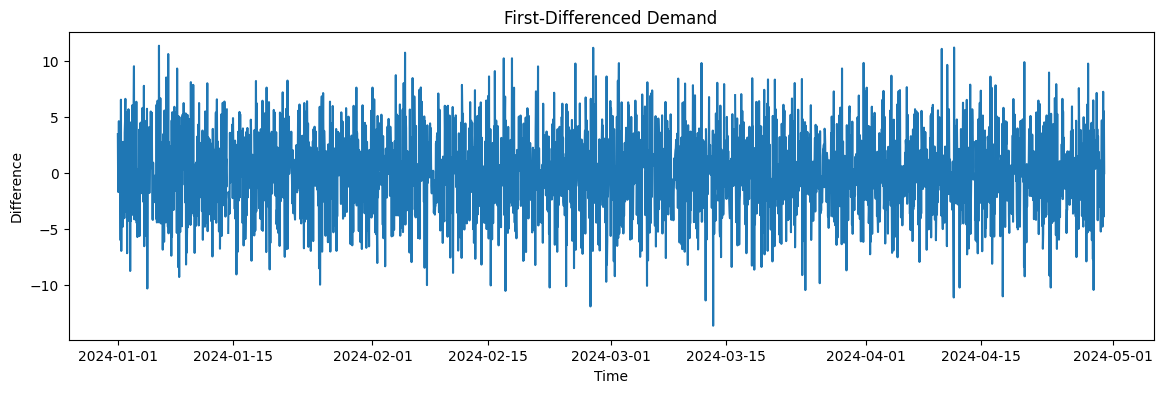

In [23]:
plt.figure(figsize=(14, 4))

plt.plot(differenced_demand.index, differenced_demand)

plt.xlabel("Time")
plt.ylabel("Difference")
plt.title("First-Differenced Demand")

plt.show()

## 27. Seasonal Differencing

For hourly data with daily seasonality:

$$
\Delta_{24}y_t = y_t-y_{t-24}
$$

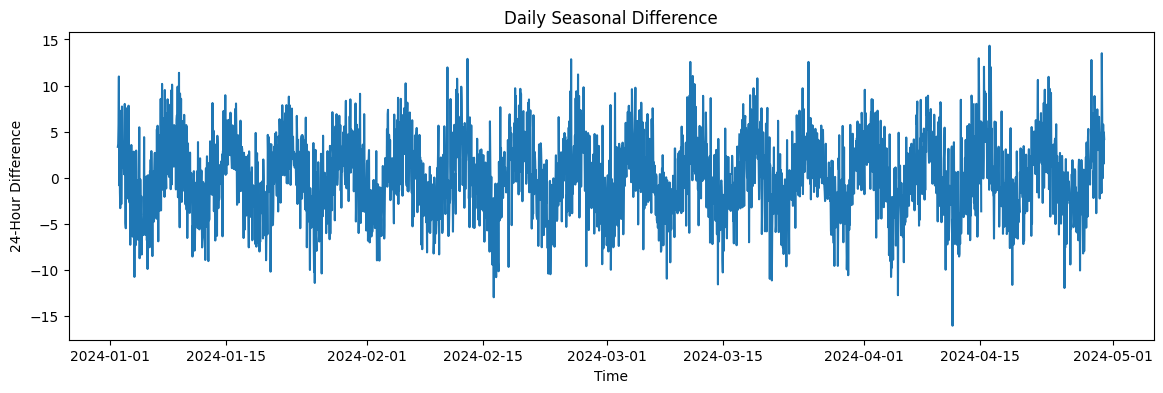

In [24]:
daily_difference = data["demand"] - data["demand"].shift(24)

plt.figure(figsize=(14, 4))

plt.plot(daily_difference.index, daily_difference)

plt.xlabel("Time")
plt.ylabel("24-Hour Difference")
plt.title("Daily Seasonal Difference")

plt.show()

## 28. Missing Values

In [25]:
missing_counts = data.isna().sum()

print("Missing values by column:")
print(missing_counts)

Missing values by column:
demand         5
temperature    0
humidity       0
dtype: int64


In [26]:
missing_demand_rows = data[data["demand"].isna()]

print("Rows with missing demand:")
print(missing_demand_rows)

Rows with missing demand:
                     demand  temperature   humidity
timestamp                                          
2024-01-14 08:00:00     NaN    25.635794  51.391871
2024-01-14 09:00:00     NaN    27.782967  50.403358
2024-02-11 16:00:00     NaN    27.459098  56.166060
2024-03-16 00:00:00     NaN    17.661667  67.081006
2024-04-14 04:00:00     NaN    19.298858  59.122153


## 29. Missing Values vs Missing Timestamps

A missing value means the timestamp exists but the measurement is absent.

A missing timestamp means the timestamp itself is absent from the index.

These are different problems.

In [27]:
expected_index = pd.date_range(
    start=data.index.min(),
    end=data.index.max(),
    freq="h"
)

missing_timestamps = expected_index.difference(data.index)

print("Number of missing timestamps:")
print(len(missing_timestamps))

print()

print(missing_timestamps)

Number of missing timestamps:
0

DatetimeIndex([], dtype='datetime64[ns]', freq='h')


## 30. Interpolate Short Missing Gaps

Interpolation can be reasonable for short gaps, but it should not be used automatically without considering the physical meaning of the data.

In [28]:
interpolated_data = data.copy()

interpolated_data["demand"] = interpolated_data["demand"].interpolate(method="time")

print("Missing demand after interpolation:")
print(interpolated_data["demand"].isna().sum())

Missing demand after interpolation:
0


## 31. Resampling

Resampling changes temporal resolution.

Examples:

```text
hourly → daily
minute → hourly
daily → weekly
```

Aggregation must match the meaning of the variable.

In [29]:
daily_average = interpolated_data["demand"].resample("D").mean()

print(daily_average.head())

timestamp
2024-01-01    54.026099
2024-01-02    56.413210
2024-01-03    55.761703
2024-01-04    52.019201
2024-01-05    49.170759
Freq: D, Name: demand, dtype: float64


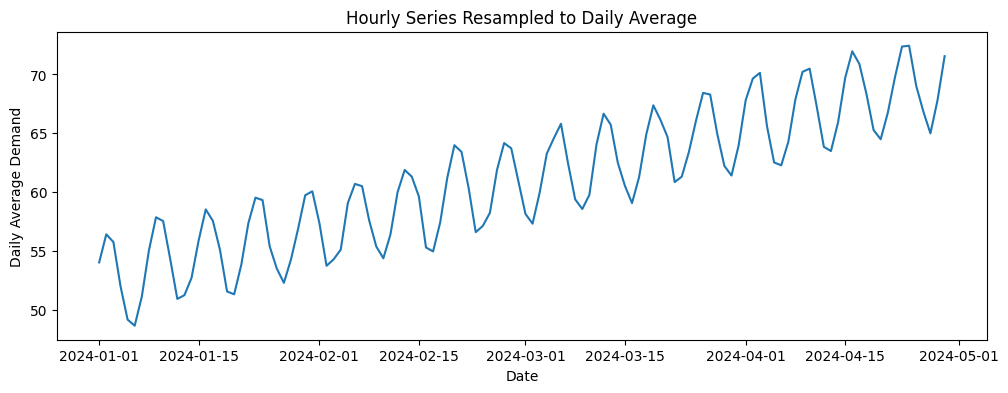

In [30]:
plt.figure(figsize=(12, 4))

plt.plot(daily_average.index, daily_average.values)

plt.xlabel("Date")
plt.ylabel("Daily Average Demand")
plt.title("Hourly Series Resampled to Daily Average")

plt.show()

## 32. Downsampling vs Upsampling

### Downsampling
Moves to a lower frequency and usually aggregates.

### Upsampling
Moves to a higher frequency and creates new timestamps that require assumptions.

Upsampling does **not** create new information.

## 33. Exogenous Variables

A target series may depend on external variables such as temperature, humidity, prices, or calendar effects.

These are often called covariates or exogenous variables.

The key forecasting question is:

> Will this variable actually be available at prediction time?

In [31]:
correlation_matrix = interpolated_data[
    ["demand", "temperature", "humidity"]
].corr()

print(correlation_matrix)

               demand  temperature  humidity
demand       1.000000    -0.188852  0.007454
temperature -0.188852     1.000000 -0.876512
humidity     0.007454    -0.876512  1.000000


## 34. What We Have Not Done Yet

No forecasting model has been built.

Before modeling, we now understand:

```text
time index
frequency
trend
seasonality
lags
autocorrelation
stationarity
missingness
resampling
covariates
```

The next notebook converts this temporal structure into leakage-free supervised-learning data.

## 35. Key Takeaways

- Time ordering is part of the data.
- Frequency determines the meaning of lags and seasonal periods.
- Trend, seasonality, cycles, and noise describe different temporal behavior.
- Lags connect the present to the past.
- Autocorrelation quantifies dependence across time.
- Rolling statistics reveal local level and variability.
- Differencing can reduce trend or seasonality.
- Missing measurements and missing timestamps are separate issues.
- Resampling changes temporal resolution.
- External variables are useful only if their availability at forecast time is valid.